In [18]:
from os import system,listdir
from pandas import DataFrame
from matplotlib import pyplot as plt

In [ ]:
for graph in listdir("MS/"):
    system(f"./rs-pancat-compare MS/{graph} MC/{graph[:-12]}1.gfa -s > dist_locale_MC/{graph[:-12]}1.tsv")
    system(f"./rs-pancat-compare MS/{graph} PGGB/{graph[:-12]}1.gfa -s > dist_locale_PGGB/{graph[:-12]}1.tsv")
# 1m 33.6s

In [ ]:
for graph in listdir("MS/"):
    system(f"./rs-pancat-compare MS/{graph} MC/{graph[:-12]}1.gfa -g dist_locale_MC/{graph[:-12]}1.tsv > dist_globale_MC/{graph[:-12]}1.tsv")
    system(f"./rs-pancat-compare MS/{graph} PGGB/{graph[:-12]}1.gfa -g dist_locale_PGGB/{graph[:-12]}1.tsv > dist_globale_PGGB/{graph[:-12]}1.tsv")
# 1298m 22.7s

In [21]:
data:dict = {
    'theta':list(),
    'cond':list(),
    'rep':list(),
    'locale_mc':list(),
    'globale_mc':list(),
    'locale_pggb':list(),
    'globale_pggb':list(),
}

for graph in listdir("MS/"):
    theta,cond,rep = graph.split('_')[0:3]
    data['theta'].append(theta)
    data['cond'].append(cond)
    data['rep'].append(rep)
    locale_mc:int = 0
    with open(f"dist_locale_MC/{graph[:-12]}1.tsv") as tsvreader:
        for line in tsvreader:
            if not line.startswith('#'):
                locale_mc += 1
    data['locale_mc'].append(locale_mc)
    globale_mc:int = 0
    with open(f"dist_globale_MC/{graph[:-12]}1.tsv") as tsvreader:
        for line in tsvreader:
            if not line.startswith('#'):
                globale_mc += 1
    data['globale_mc'].append(globale_mc)
    locale_pggb:int = 0
    with open(f"dist_locale_PGGB/{graph[:-12]}1.tsv") as tsvreader:
        for line in tsvreader:
            if not line.startswith('#'):
                locale_pggb += 1
    data['locale_pggb'].append(locale_pggb)
    globale_pggb:int = 0
    with open(f"dist_globale_PGGB/{graph[:-12]}1.tsv") as tsvreader:
        for line in tsvreader:
            if not line.startswith('#'):
                globale_pggb += 1
    data['globale_pggb'].append(globale_pggb)


df = DataFrame(data)
df

,theta,cond,rep,locale_mc,globale_mc,locale_pggb,globale_pggb
0,SA,D,rep7,110377,12096,46791,4136
1,SA,D,rep6,132337,14219,76072,6420
2,SAH,C,rep24,304592,75532,188768,36347
3,SAH,B,rep2,104270,41436,69404,24288
4,SA,C,rep13,43181,9578,24798,4052
...,...,...,...,...,...,...,...
235,SAH,D,rep4,1029672,139670,451274,43046
236,SA,C,rep2,43881,9430,23111,3756
237,SAH,A,rep3,9935,6823,8029,5764
238,SAH,B,rep23,100296,42883,57990,19921


Text(0.5, 0.98, 'Distance')

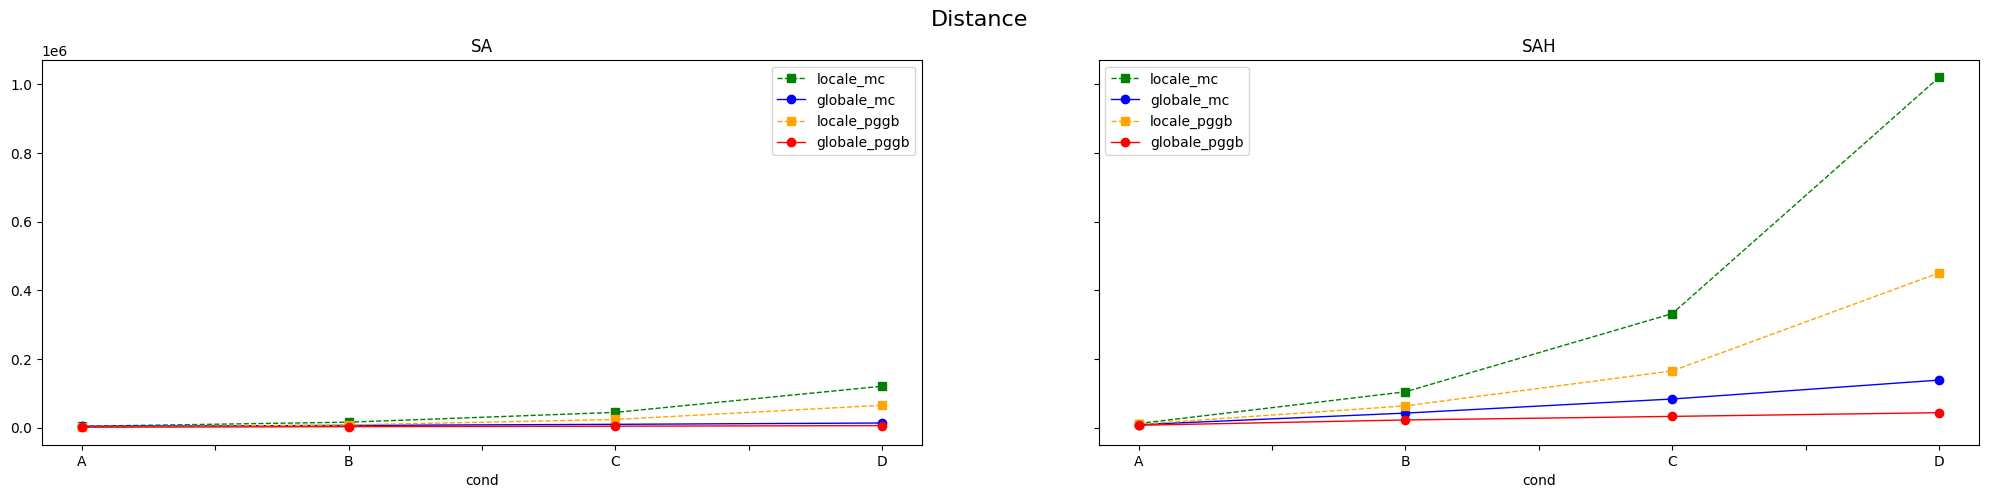

In [49]:
fig, axs = plt.subplots(1,2,figsize=(25,5),sharey=True)
for label_cond,cl in df.groupby('theta'):
    dict_assign = {'SA':0,'SAH':1}
    cl.groupby("cond").locale_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="locale MC",marker='s',linewidth=1,linestyle='--',color='green')
    cl.groupby("cond").globale_mc.mean().plot(ax=axs[dict_assign[label_cond]],legend="globale MC",marker='o',linewidth=1,color='blue')
    cl.groupby("cond").locale_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="locale PGGB",marker='s',linewidth=1,linestyle='--',color='orange')
    cl.groupby("cond").globale_pggb.mean().plot(ax=axs[dict_assign[label_cond]],legend="globale PGGB",marker='o',linewidth=1,color='red')
    for key,val in dict_assign.items():
        axs[val].set_title(key)
        #axs[val].set_ylim(0,1)
fig.suptitle('Distance', fontsize=16)

In [ ]:
locale_mc = dict()
locale_pggb = dict()
globale_mc = dict()
globale_pggb = dict()

for label_cond,cl in df.groupby('theta'):
    dict_assign = {'SA':0,'SAH':1}
    locale_mc[label_cond] = cl.groupby("cond").locale_mc.mean()
    globale_mc[label_cond] = cl.groupby("cond").globale_mc.mean()
    locale_pggb[label_cond] = cl.groupby("cond").locale_pggb.mean()
    globale_pggb[label_cond] = cl.groupby("cond").globale_pggb.mean()

ratios_mc_locale = locale_mc['SA']/locale_mc['SAH']
ratios_pggb_locale = locale_pggb['SA']/locale_pggb['SAH']
ratios_mc_globale = globale_mc['SA']/globale_mc['SAH']
ratios_pggb_globale = globale_pggb['SA']/globale_pggb['SAH']

Text(0.5, 0.98, 'Ratio des distances')

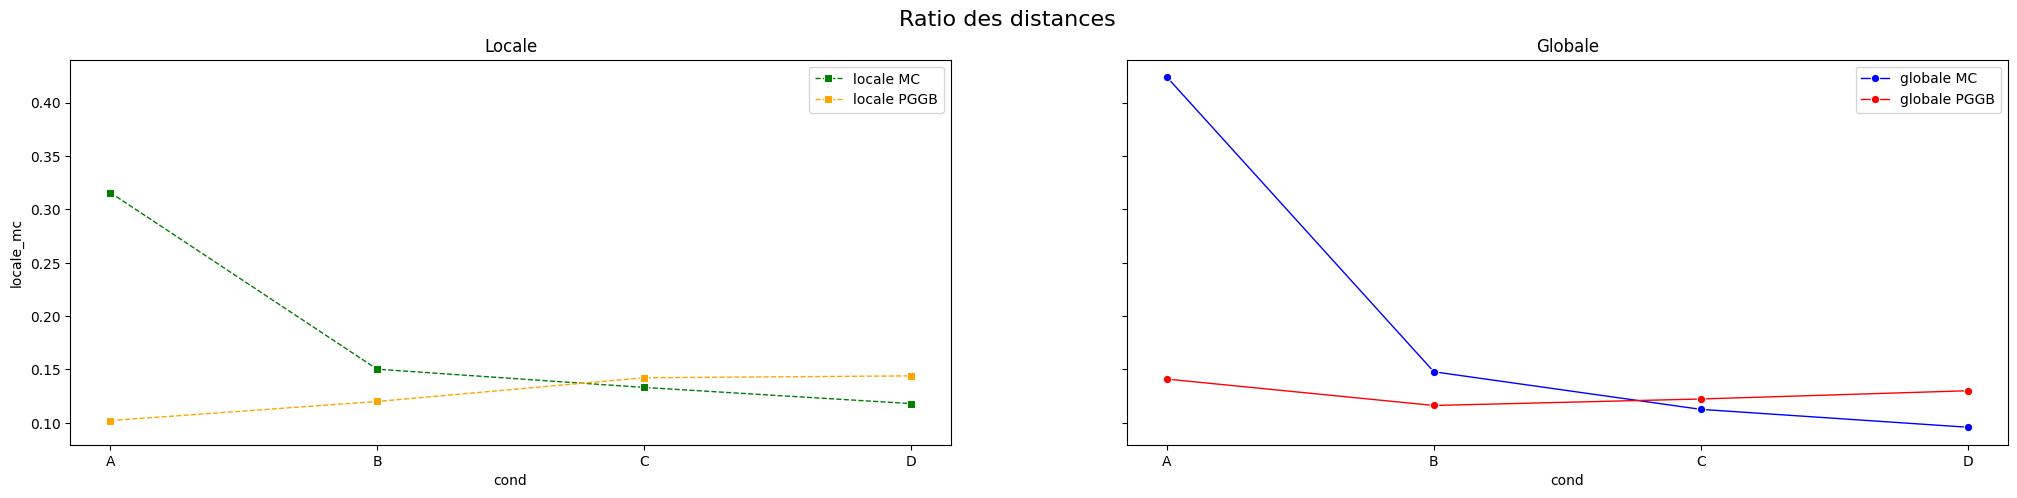

In [47]:
fig, axs = plt.subplots(1,2,figsize=(25,5),sharey=True)
import seaborn as sns

sns.lineplot(ratios_mc_locale,ax=axs[0],label="locale MC",marker='s',linewidth=1,linestyle='--',color='green')
sns.lineplot(ratios_pggb_locale,ax=axs[0],label="locale PGGB",marker='s',linewidth=1,linestyle='--',color='orange')

sns.lineplot(ratios_mc_globale,ax=axs[1],label="globale MC",marker='o',linewidth=1,color='blue')
sns.lineplot(ratios_pggb_globale,ax=axs[1],label="globale PGGB",marker='o',linewidth=1,color='red')

axs[0].set_title('Locale')
axs[1].set_title('Globale')

fig.suptitle('Ratio des distances', fontsize=16)

In [50]:
# inversion ratios

ratios_mc_locale = locale_mc['SAH']/locale_mc['SA']
ratios_pggb_locale = locale_pggb['SAH']/locale_pggb['SA']
ratios_mc_globale = globale_mc['SAH']/globale_mc['SA']
ratios_pggb_globale = globale_pggb['SAH']/globale_pggb['SA']

Text(0.5, 0.98, 'Ratio des distances')

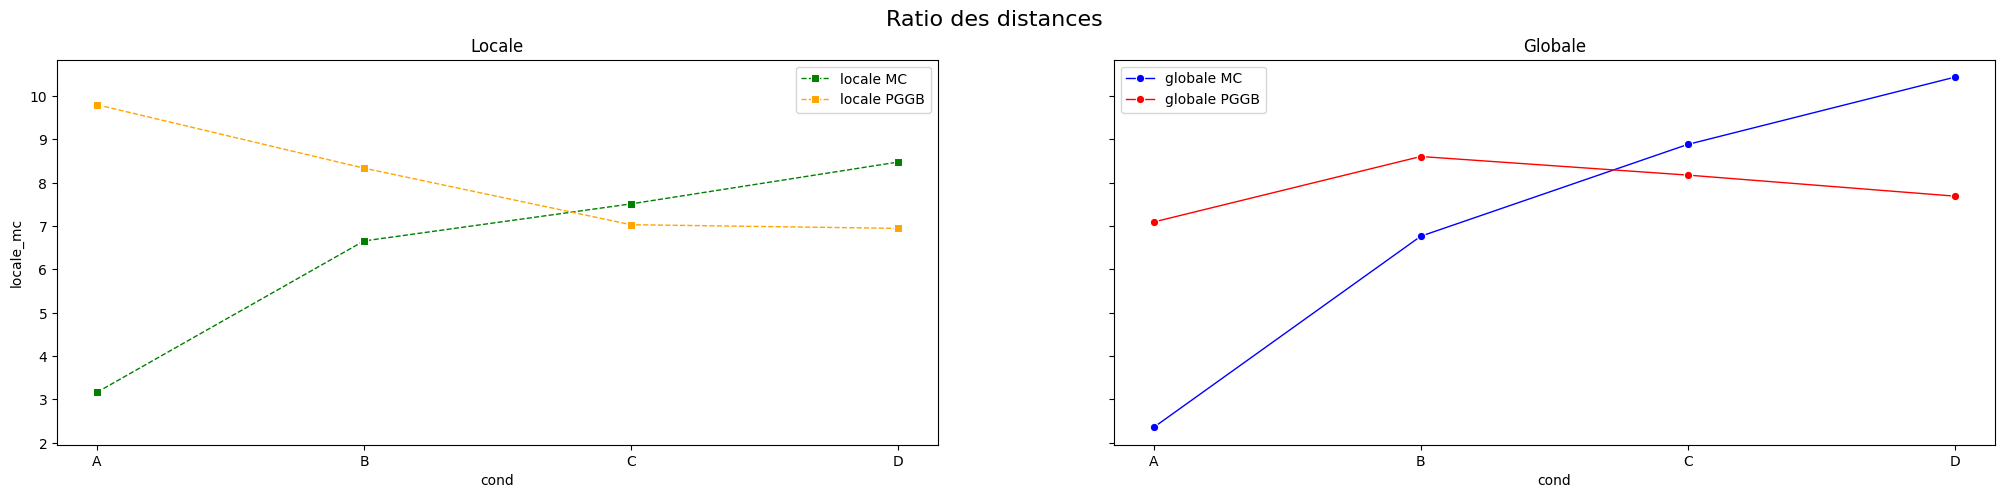

In [51]:
fig, axs = plt.subplots(1,2,figsize=(25,5),sharey=True)
import seaborn as sns

sns.lineplot(ratios_mc_locale,ax=axs[0],label="locale MC",marker='s',linewidth=1,linestyle='--',color='green')
sns.lineplot(ratios_pggb_locale,ax=axs[0],label="locale PGGB",marker='s',linewidth=1,linestyle='--',color='orange')

sns.lineplot(ratios_mc_globale,ax=axs[1],label="globale MC",marker='o',linewidth=1,color='blue')
sns.lineplot(ratios_pggb_globale,ax=axs[1],label="globale PGGB",marker='o',linewidth=1,color='red')

axs[0].set_title('Locale')
axs[1].set_title('Globale')

fig.suptitle('Ratio des distances', fontsize=16)